# Beginner Friendly CATBOOST with OPTUNA

## Data

**Attribute Information**

Age: age of the patient [years]

Sex: sex of the patient [M: Male, F: Female]

ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

RestingBP: resting blood pressure [mm Hg]

Cholesterol: serum cholesterol [mm/dl]

FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]

ExerciseAngina: exercise-induced angina [Y: Yes, N: No]

Oldpeak: oldpeak = ST [Numeric value measured in depression]

ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]

HeartDisease: output class [1: heart disease, 0: Normal]

## Exploratory Data Analysis

In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedStratifiedKFold,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder, StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer

from sklearn.model_selection import KFold, cross_val_predict, train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score,classification_report

# import plotly and cufflinks in offline mode
import cufflinks as cf
import plotly.offline
cf.go_offline()
cf.set_config_file(offline=False,world_readable=True)

import plotly 
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import missingno as msno

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set display
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',900)
pd.set_option('display.max_colwidth',200)

# Load dataset
df = pd.read_csv('./heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.info()
# overall data types seems ok

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# Checking duplicated
df.duplicated().sum()
# no duplicates

0

In [ ]:
print(df.isnull().sum())
print(df.count())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Age               918
Sex               918
ChestPainType     918
RestingBP         918
Cholesterol       918
FastingBS         918
RestingECG        918
MaxHR             918
ExerciseAngina    918
Oldpeak           918
ST_Slope          918
HeartDisease      918
dtype: int64


In [ ]:
# Checking missing data(NaN)
def missing(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number,missing_percent],axis=1,keys=['Missing_Number','Missing_Percent'])
    return missing_values

missing(df) 
# No missing values


,Missing_Number,Missing_Percent
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


In [ ]:
# .columns : access column names
# select_dtypes : select columns by data type
numerical = df.drop(['HeartDisease'],axis=1).select_dtypes('number').columns
categorical = df.select_dtypes('object').columns
print(f'Numerical columns: {numerical}')
print(f'Categorical Columns: {categorical}')

Numerical columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')
Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [ ]:
# nunique() : number of unique values 
df[categorical].nunique()

Sex               2
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
dtype: int64

### Target Variable

In [ ]:
y = df['HeartDisease']
print(y.value_counts())
# % of class 1 in a target var(HeartDisease)
# normalize : returns proportions 
    # e.g., for class 1, appears 508 times out of 918 
            # 508/(508+410) = 508/918 = 0.55 
y.value_counts(normalize=True)[1]*100

HeartDisease
1    508
0    410
Name: count, dtype: int64


55.33769063180828

In [ ]:
y = df['HeartDisease']
print(f'Percentage of patient had a HeartDisease: {round(y.value_counts(normalize=True)[1]*100,2)}% --> ({y.value_counts()[1]} patient)\n'
      f'Percentage of patient did not have a HeartDisease: {round(y.value_counts(normalize=True)[0]*100,2)}% --> ({y.value_counts()[0]} patient)')

# Almost 55% of patients had a heart disease
# 508 patient had a heart disease
# Almost 45% of patients didn't have a heart disease.
# 410 patient didn't have a heart disease.

Percentage of patient had a HeartDisease: 55.34% --> (508 patient)
Percentage of patient did not have a HeartDisease: 44.66% --> (410 patient)


In [ ]:
df['HeartDisease'].iplot(kind='hist')

# a little imbalance but not much disturbing -> can use 'accuracy' metric as our evaluation metric

### Numerical Features

In [ ]:
df[numerical].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000


In [ ]:
df[numerical].iplot(kind='hist')

In [ ]:
# bins=50 : divides col into 50 equal width bins
df[numerical].iplot(kind='hist',subplots=True,bins=50)

In [ ]:
df['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

In [ ]:
# Detect Skewed Features
skew_limit = 0.75 # threshold for what is considered too skewed
# 0:normal distribution(perfectly symmetrical), >0:right skewed, <0:left skewed
# |skewness|<0.75 (acceptable)
# |skewness|>0.75 (require transformation)
# .skew() : calculate skewness
skew_vals = df[numerical].drop('FastingBS',axis=1).skew()
skew_cols = skew_vals[abs(skew_vals)>skew_limit].sort_values(ascending=False)
skew_cols

# Not much for skewnewss, quite like normal distribution 

Oldpeak    1.022872
dtype: float64

In [ ]:
skew_vals

Oldpeak    1.022872
dtype: float64

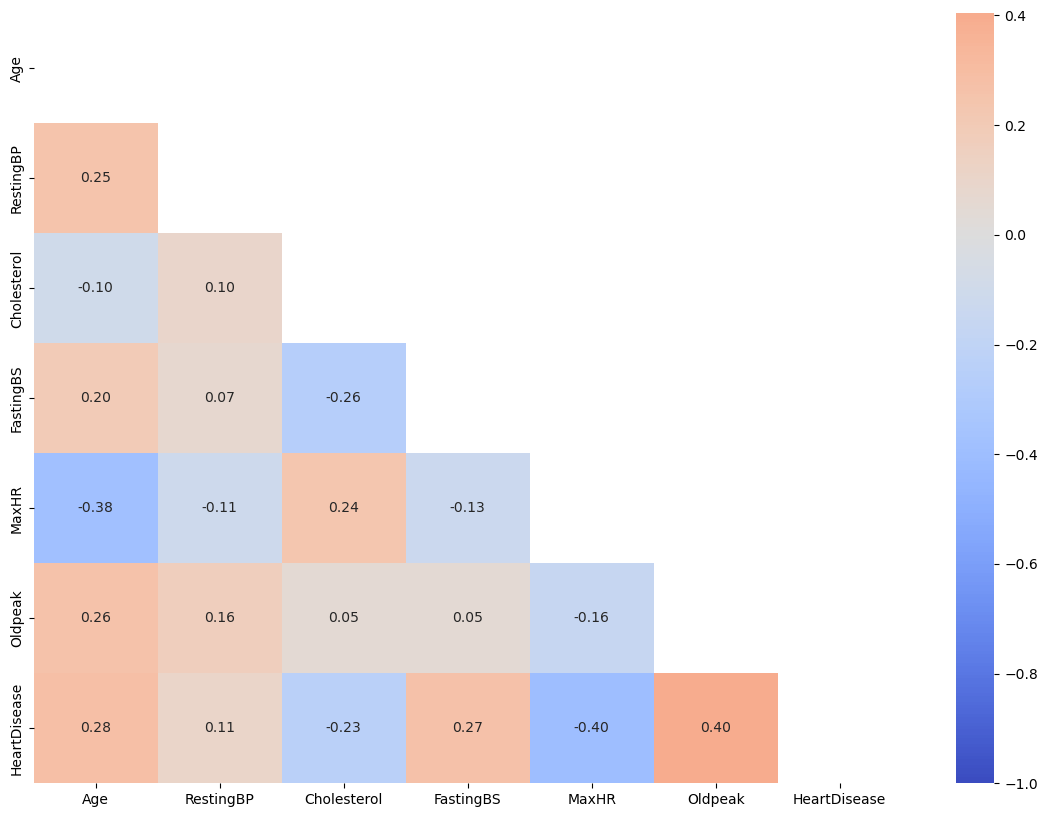

In [ ]:
# Correlation heatmap of numerical features (masking upper triangle to avoid repeating values)
# including HeartDisease
numerical1 = df.select_dtypes('number').columns
# upper triangle
matrix = np.triu(df[numerical1].corr())
fig,ax = plt.subplots(figsize=(14,10))
sns.heatmap(df[numerical1].corr(),annot=True,fmt='.2f',vmin=-1,center=0,cmap='coolwarm',mask=matrix, ax=ax);

# 1:perfect positive correlation(increase-increase), 0:no linear correlation, -1:perfect negative correlation(increase-decrease)
# Based on the matrix, can observe
# weak correlation between numerical features & target var(HeartDisease)
# OldPeak(depression related num) has highest positive cor with heart disease
# MaxHR(maximum heart rate) has highest negative cor with heart disease
# interestingly, cholesterol has negative cor with heart disease

In [ ]:
df[numerical].corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000


### Categorical Features

In [ ]:
df[categorical].head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


In [ ]:
# Gender & Heart Disease

print(f'A female person has a probability of {round(df[df["Sex"]=="F"]["HeartDisease"].mean()*100,2)}% have a HeartDisease\n'
      f'A male person has a probability of {round(df[df["Sex"]=="M"]["HeartDisease"].mean()*100,2)}% have a HeartDisease')

A female person has a probability of 25.91% have a HeartDisease
A male person has a probability of 63.17% have a HeartDisease


In [ ]:
df[df["Sex"]=="F"]["HeartDisease"][:10]

1     1
3     1
6     0
9     0
10    0
14    0
15    0
17    0
20    0
22    0
Name: HeartDisease, dtype: int64

In [ ]:
fig = px.histogram(df,x="Sex",color="HeartDisease",width=400,height=400)
fig.show()

# Men are almost 2.44(0.6317/0.2591) times more likely to have a heart disease than women

In [ ]:
# Chest Pain Type & Heart Disease
df.groupby('ChestPainType')['HeartDisease'].mean().sort_values(ascending=False)


ChestPainType
ASY    0.790323
TA     0.434783
NAP    0.354680
ATA    0.138728
Name: HeartDisease, dtype: float64

In [ ]:
fig = px.histogram(df,x="ChestPainType",color="HeartDisease",width=400,height=400)
fig.show()

# Can observe clear differences among chest pain types.
# Person with ASY(asymptomatic chest pain)has almost 6 times(0.79/0.13) more likely to have a heart disease than person with ATA(atypical angina chest pain)

In [ ]:
# RestingECG & Heart Disease
df.groupby('RestingECG')['HeartDisease'].mean().sort_values(ascending=False)

RestingECG
ST        0.657303
LVH       0.563830
Normal    0.516304
Name: HeartDisease, dtype: float64

In [ ]:
fig = px.histogram(df,x='RestingECG',color='HeartDisease',width=400,height=400)
fig.show()

# All types show quite similar results
# Person with sT(having ST-T wave abnormality) is more likely to have a heart disease than others

In [ ]:
# ExerciseAngina and Heart Disease
df.groupby('ExerciseAngina')['HeartDisease'].mean().sort_values(ascending=False)

ExerciseAngina
Y    0.851752
N    0.351005
Name: HeartDisease, dtype: float64

In [ ]:
fig = px.histogram(df, x="ExerciseAngina", color="HeartDisease",width=400, height=400)
fig.show()

# ExerciseAngina with 'Yes' almost 2.4 times more likely to have a heart disease than 'No'

In [ ]:
# ST_Slope & HeartDisease
df.groupby('ST_Slope')['HeartDisease'].mean().sort_values(ascending=False)

ST_Slope
Flat    0.828261
Down    0.777778
Up      0.197468
Name: HeartDisease, dtype: float64

In [ ]:
fig = px.histogram(df, x="ST_Slope", color="HeartDisease",width=400, height=400)
fig.show()

# slope of peak exercise ST segment differ.
# Up significantly less likely to have a heart disease than the other two segments.

**Overall insights from Exploratory Data Analysis**

Target variable is closed to balanced data.

Numerical features have weak correlation with the target variable.

Oldpeak (depression related number) has a positive correlation with the heart disease.

Maximum heart rate has negative correlation with the heart disease.

Interestingly cholesterol has negative correlation with the heart disease.

Based on gender; Men are almost 2.44 times more likely have a heart disease than women.

We can observe clear differences among the chest pain type.
Person with ASY: Asymptomatic chest pain has almost 6 times more likely have a heart disease than person with ATA Atypical Angina chest pain.

RestingECG: resting electrocardiogram results don't differ much.
Person with ST: having ST-T wave abnormality is more likely have a heart disease than the others.

ExerciseAngina: exercise-induced angina with 'Yes' almost 2.4 times more likley have a heart disaese than exercise-induced angina with 'No'

ST_Slope: the slope of the peak exercise ST segment has differences.
ST_Slope Up significantly less likely has heart disease than the other two segment.

## Model Selection

### Baseline Model

In [ ]:
accuracy = []
model_names = []

# Feature
X = df.drop('HeartDisease',axis=1)
# Label
y = df['HeartDisease']
# Split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Data Preprocessing
one = OneHotEncoder()
# apply ohe to categorical columns & passes through numeric ones
ct = make_column_transformer((one,categorical),remainder='passthrough')

# Train
# Define
# define dummy classifier that makes constant predictions, always predicts class 1(HeartDisease yes) 
model = DummyClassifier(strategy='constant',constant=1)
# Build pipeline (to combines preprocessing and model into one pipeline)
pipe = make_pipeline(ct,model)
# Fit
pipe.fit(X_train,y_train)

# Predict
y_pred = pipe.predict(X_test)
# Evaluate
score = round(accuracy_score(y_test,y_pred),4)
accuracy.append(score)
print(f'model: {model} and accuracy score is {score}')

model_names.append('DummyClassifier')
# Make into DataFrame
dummy_result_df = pd.DataFrame({'Accuracy':accuracy},index=model_names)
dummy_result_df


model: DummyClassifier(constant=1, strategy='constant') and accuracy score is 0.5942


,Accuracy
DummyClassifier,0.5942


### Logistic & Linear Discriminant SVC & KNN

In [ ]:
accuracy = []
model_names = []
# Feature 
X = df.drop('HeartDisease',axis=1)
# Label
y = df['HeartDisease']
# Split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
# Pre-process
ohe = OneHotEncoder()
ct = make_column_transformer((ohe,categorical),remainder='passthrough')
# Define models
lr = LogisticRegression(solver='liblinear')
lda = LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]
for model in models:
    # Make pipeline
    pipe = make_pipeline(ct,model)
    # Fit
    pipe.fit(X_train,y_train)
    # Predict
    y_pred=pipe.predict(X_test)
    score = accuracy.append(round(accuracy_score(y_test,y_pred),4))
    print (f'model : {model} and  accuracy score is : {score}')

model_names = ['Logistic','LinearDiscriminant','SVM','KNeighbors']
result_df1 = pd.DataFrame({'Accuracy':accuracy},index=model_names)
result_df1

model : LogisticRegression(solver='liblinear') and  accuracy score is : None
model : LinearDiscriminantAnalysis() and  accuracy score is : None
model : SVC() and  accuracy score is : None
model : KNeighborsClassifier() and  accuracy score is : None


,Accuracy
Logistic,0.8841
LinearDiscriminant,0.8696
SVM,0.7246
KNeighbors,0.7174


### Logistic & Linear Discriminant SVC & KNN with Scaler

In [ ]:
accuracy =[]
model_names =[]

# Feature
X= df.drop('HeartDisease', axis=1)
# Label
y= df['HeartDisease']
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Pre-process
ohe= OneHotEncoder()
s= StandardScaler()
ct1= make_column_transformer((ohe,categorical),(s,numerical))  

# Define models
lr = LogisticRegression(solver='liblinear')
lda= LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]

for model in models: 
    # Make pipeline
    pipe = make_pipeline(ct1, model)
    # Fit
    pipe.fit(X_train, y_train)
    # Predict
    y_pred = pipe.predict(X_test)
    # Evaluate
    score = round(accuracy_score(y_test, y_pred),4)
    accuracy.append(score)
    print (f'model : {model} and  accuracy score is : {score}')

model_names = ['Logistic_scl','LinearDiscriminant_scl','SVM_scl','KNeighbors_scl']
result_df2 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df2

# with scaler, both KNN & SVM did a better job

model : LogisticRegression(solver='liblinear') and  accuracy score is : 0.8804
model : LinearDiscriminantAnalysis() and  accuracy score is : 0.8696
model : SVC() and  accuracy score is : 0.8841
model : KNeighborsClassifier() and  accuracy score is : 0.8841


,Accuracy
Logistic_scl,0.8804
LinearDiscriminant_scl,0.8696
SVM_scl,0.8841
KNeighbors_scl,0.8841


### Ensemble Models (AdaBoost & Gradient Boosting & Random Forest & Extra Trees)

In [ ]:
accuracy = []

# Feature
X = df.drop("HeartDisease",axis=1)
# Label
y = df["HeartDisease"]
# Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Preprocess
ohe = OneHotEncoder()
ct = make_column_transformer((ohe,categorical),remainder="passthrough")

# Define models
ada = AdaBoostClassifier(random_state=0)
gb = GradientBoostingClassifier(random_state=0)
rf = RandomForestClassifier(random_state=0)
et = ExtraTreesClassifier(random_state=0)

models = [ada,gb,rf,et]
for model in models:
    # Make pipeline
    pipe = make_pipeline(ct,model)
    # Fit
    pipe.fit(X_train,y_train)
    # Predict
    y_pred = pipe.predict(X_test)
    # Evaluate
    score = round(accuracy_score(y_test,y_pred),4)
    accuracy.append(score)
    print (f'model : {model} and  accuracy score is : {score}')

model_names = ['Ada','Gradient','Random','ExtraTree']
result_df3 = pd.DataFrame({'Accuracy':accuracy},index=model_names)
result_df3

# Accuracy score similar to each other.
# Both random forest and extra tree got similar accuracy score in which both can be improved by hyperparameter tuning


model : AdaBoostClassifier(random_state=0) and  accuracy score is : 0.8659
model : GradientBoostingClassifier(random_state=0) and  accuracy score is : 0.8768
model : RandomForestClassifier(random_state=0) and  accuracy score is : 0.8877
model : ExtraTreesClassifier(random_state=0) and  accuracy score is : 0.8696


,Accuracy
Ada,0.8659
Gradient,0.8768
Random,0.8877
ExtraTree,0.8696


### Famous Trio (XGBoost & LightGBM & Catboost)

In [ ]:
accuracy = []

# Feature
X = df.drop("HeartDisease",axis=1)
# Label
y = df["HeartDisease"]
# Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Preprocess
ohe = OneHotEncoder()
ct = make_column_transformer((ohe,categorical),remainder="passthrough")

# Define models
xgbc = XGBClassifier(random_state=0)
lgbmc = LGBMClassifier(random_state=0)

models = [xgbc,lgbmc]
for model in models:
    # Make pipeline
    pipe = make_pipeline(ct,model)
    # Fit
    pipe.fit(X_train,y_train)
    # Predict
    y_pred = pipe.predict(X_test)
    # Evaluate
    score = round(accuracy_score(y_test,y_pred),4)
    accuracy.append(score)
    print (f'model : {model} and  accuracy score is : {score}')

model_names = ['XGBoost','LightGBM']
result_df4 = pd.DataFrame({'Accuracy':accuracy},index=model_names)
result_df4



model : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) and  accuracy score is : 0.8478
[LightGBM] [Info] Number of positive: 344, number of negative: 298
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001938 seconds.
You can set `force_row_wise=

,Accuracy
XGBoost,0.8478
LightGBM,0.8732


### CATBOOST

Categorical Boosting
- handles categorical features directly (no need to do encoding)

In [ ]:
accuracy =[]
model_names =[]

X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != float)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0)

model.fit(X_train, y_train,cat_features=categorical_features_indices,eval_set=(X_test, y_test))
y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))

model_names = ['Catboost_default']
result_df5 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df5

,Accuracy
Catboost_default,0.8804


In [ ]:
categorical_features_indices = np.where(X.dtypes != float)[0]
categorical_features_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10])

In [ ]:
X.iloc[:5,:]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Catboost HyperParameter Tuning with OPTUNA

In [ ]:
def objective(trial):
    X = df.drop('HeartDisease',axis=1)
    y = df['HeartDisease']
    # Select categorical data where they are not float
    categorical_features_indices = np.where(X.dtypes!=float)[0]
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
    # Search Space
    param = {
        # tells CatBoost what loss function to use for binary classification
        "objective": trial.suggest_categorical("objective",["Logloss","CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01,0.1),
        'depth': trial.suggest_int('depth',1,12),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "used_ram_limit": "3gb",
    }
    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1)
    # Define model
    cat_cls = CatBoostClassifier(**param)
    # Fit
    cat_cls.fit(X_train,y_train,eval_set=[(X_test,y_test)],cat_features=categorical_features_indices,verbose=0,early_stopping_rounds=100)
    # Predict 
    preds = cat_cls.predict(X_test)
    # rounds predictions to the nearest integer(0 or 1)
    pred_labels = np.rint(preds)
    # Evaluate
    accuracy = accuracy_score(y_test,pred_labels)
    return accuracy

if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))



[I 2025-04-07 02:41:38,342] A new study created in memory with name: no-name-efde3aba-cf2f-4e32-a93b-ce3b7c64b3e1
[I 2025-04-07 02:41:38,884] Trial 0 finished with value: 0.8804347826086957 and parameters: {'objective': 'Logloss', 'colsample_bylevel': 0.056945074485835565, 'depth': 5, 'boosting_type': 'Plain', 'bootstrap_type': 'Bayesian', 'bagging_temperature': 2.769807863868028}. Best is trial 0 with value: 0.8804347826086957.
[I 2025-04-07 02:41:39,700] Trial 1 finished with value: 0.8913043478260869 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.07660300669365809, 'depth': 1, 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS'}. Best is trial 1 with value: 0.8913043478260869.
[I 2025-04-07 02:41:40,431] Trial 2 finished with value: 0.8913043478260869 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.02773297272485089, 'depth': 8, 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS'}. Best is trial 1 with value: 0.8913043478260869.
[I 2025-04-

Number of finished trials: 50
Best trial:
  Value: 0.8985507246376812
  Params: 
    objective: Logloss
    colsample_bylevel: 0.054353486236662245
    depth: 9
    boosting_type: Ordered
    bootstrap_type: MVS


In [ ]:
accuracy =[]

X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != float)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0,objective='Logloss',colsample_bylevel=0.054353486236662245,depth=9,boosting_type='Ordered',bootstrap_type='MVS')
model.fit(X_train,y_train,cat_features=categorical_features_indices,eval_set=(X_test,y_test))

y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test,y_pred),4))
print(classification_report(y_test,y_pred))

model_names = ['CatBoost_tuned']
result_df6 = pd.DataFrame({'Accuracy':accuracy},index=model_names)
result_df6

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       112
           1       0.93      0.90      0.91       164

    accuracy                           0.90       276
   macro avg       0.89      0.90      0.90       276
weighted avg       0.90      0.90      0.90       276



,Accuracy
CatBoost_tuned,0.8986


### Feature Importance

In [ ]:
feature_importance = np.array(model.get_feature_importance())
features = np.array(X_train.columns)
fi = {'features':features,'feature_importance':feature_importance}
df_fi = pd.DataFrame(fi)
df_fi.sort_values(by=['feature_importance'],ascending=True,inplace=True)
fig = px.bar(df_fi,x='feature_importance',y='features',title='CatBoost Feature Importance',height=500)
fig.show()

In [ ]:
feature_importance = np.array(model.get_feature_importance())
feature_importance 

array([ 6.50244693,  6.63900771, 11.35365107,  5.50167149,  7.81490071,
        7.23558745,  3.43910248,  4.99768833, 10.4797456 , 13.17200326,
       22.86419498])

### Model Comparison

In [ ]:
result_final = pd.concat([dummy_result_df,result_df1,result_df2,result_df3,result_df4,result_df5,result_df6],axis=0)
result_final

,Accuracy
DummyClassifier,0.5942
Logistic,0.8841
LinearDiscriminant,0.8696
SVM,0.7246
KNeighbors,0.7174
Logistic_scl,0.8804
LinearDiscriminant_scl,0.8696
SVM_scl,0.8841
KNeighbors_scl,0.8841
Ada,0.8659


In [ ]:
result_final.sort_values(by='Accuracy',ascending=True,inplace=True)
fig = px.bar(result_final,x='Accuracy',y=result_final.index,title='Model Comparison',height=600,labels={'index':'MODELS'})
fig.show()

In [ ]:
result_final.index

Index(['DummyClassifier', 'Logistic', 'LinearDiscriminant', 'SVM',
       'KNeighbors', 'Logistic_scl', 'LinearDiscriminant_scl', 'SVM_scl',
       'KNeighbors_scl', 'Ada', 'Gradient', 'Random', 'ExtraTree', 'XGBoost',
       'LightGBM', 'Catboost_default', 'CatBoost_tuned'],
      dtype='object')

**Conclusion (Classification of Heart Disease cases)**
- Made detailed exploratory analysis
- Decided which metric to use
- Analyze Target & Features in detail
- Transform categorical variables into numeric to use them in the model
- Use pipeline to avoid data leakage
- Look at results of each model and selected best one
- Look in detail of Catboost
- Made hyperparameter tuning of Catboost with Optuna to see the improvement
- Look at feature of importance